In [1]:
# Random Forest Classifier for Loan Default Prediction
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score

import warnings
warnings.filterwarnings('ignore')

# Add src folder to path for custom modules
sys.path.append('../src')
from evaluation import evaluate_model, plot_confusion_matrix, plot_roc_curve
from utils import load_processed_data, get_features_and_target, plot_feature_importance, print_dataset_info

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load preprocessed data
# ======================

# Load all processed datasets using utils
datasets = load_processed_data()

# Get features and target for training data (SMOTE balanced)
X_train, y_train = get_features_and_target(datasets['train'])

# Get features and target for test data
X_test, y_test = get_features_and_target(datasets['test'])

# Print dataset info
print_dataset_info(datasets['train'], 'Training Set (SMOTE)')
print_dataset_info(datasets['test'], 'Test Set')


Training Set (SMOTE) Information
Shape: (56604, 23)
Columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'HasMortgage', 'HasDependents', 'HasCoSigner', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other', 'Default']

Target distribution:
Default
0    28302
1    28302
Name: count, dtype: int64

Test Set Information
Shape: (8000, 23)
Columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'HasMortgage', 'HasDependents', 'HasCoSigner', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home',

In [3]:
# Baseline Random Forest Model
# ============================

rf_baseline = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

# Predictions
y_pred_baseline = rf_baseline.predict(X_test)
y_prob_baseline = rf_baseline.predict_proba(X_test)[:, 1]

print("Baseline Random Forest trained!")

Baseline Random Forest trained!



Random Forest (Baseline) Evaluation Results
ACCURACY    : 0.8781
PRECISION   : 0.4132
RECALL      : 0.1286
F1_SCORE    : 0.1962
AUC_ROC     : 0.7287

Classification Report:
              precision    recall  f1-score   support

  No Default       0.90      0.98      0.93      7075
     Default       0.41      0.13      0.20       925

    accuracy                           0.88      8000
   macro avg       0.65      0.55      0.57      8000
weighted avg       0.84      0.88      0.85      8000



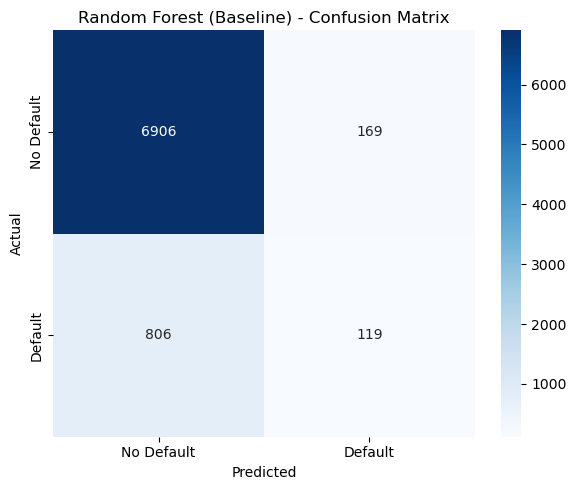

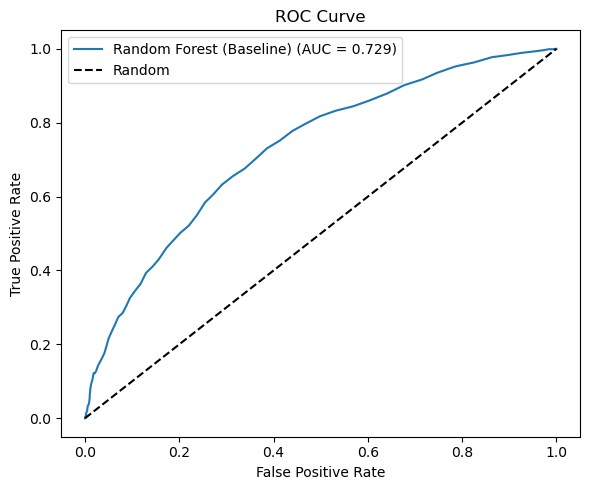

0.7287210008595169

In [4]:
# Evaluate Baseline Model
# =======================

baseline_metrics = evaluate_model(y_test, y_pred_baseline, y_prob_baseline, 'Random Forest (Baseline)')
plot_confusion_matrix(y_test, y_pred_baseline, 'Random Forest (Baseline)')
plot_roc_curve(y_test, y_prob_baseline, 'Random Forest (Baseline)')

In [ ]:
# Hyperparameter Tuning with GridSearchCV
# ========================================

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Starting GridSearchCV... (this may take a few minutes)")
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")

Starting GridSearchCV... (this may take a few minutes)
Fitting 5 folds for each of 108 candidates, totalling 540 fits


In [ ]:
# Evaluate Tuned Model
# ====================

rf_tuned = grid_search.best_estimator_

y_pred_tuned = rf_tuned.predict(X_test)
y_prob_tuned = rf_tuned.predict_proba(X_test)[:, 1]

tuned_metrics = evaluate_model(y_test, y_pred_tuned, y_prob_tuned, 'Random Forest (Tuned)')
plot_confusion_matrix(y_test, y_pred_tuned, 'Random Forest (Tuned)')
plot_roc_curve(y_test, y_prob_tuned, 'Random Forest (Tuned)')

In [ ]:
# Feature Importance
# ==================

# Use utils function to plot and get feature importance
feature_importance = plot_feature_importance(
    feature_names=X_train.columns,
    importances=rf_tuned.feature_importances_,
    top_n=15,
    title='Random Forest - Top 15 Feature Importances'
)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

In [ ]:
# Model Comparison: Baseline vs Tuned
# ====================================

from evaluation import compare_models

results = {
    'RF Baseline': baseline_metrics,
    'RF Tuned': tuned_metrics
}

comparison_df = compare_models(results)

In [ ]:
# Save Best Model
# ===============

import joblib

# Save tuned model
joblib.dump(rf_tuned, '../models/random_forest_tuned.pkl')

# Save feature importance
feature_importance.to_csv('../results/rf_feature_importance.csv', index=False)

# Save metrics
metrics_df = pd.DataFrame([tuned_metrics])
metrics_df['model'] = 'Random Forest (Tuned)'
metrics_df.to_csv('../results/rf_metrics.csv', index=False)

print("Model and results saved successfully!")
print("- Model: ../models/random_forest_tuned.pkl")
print("- Feature importance: ../results/rf_feature_importance.csv")
print("- Metrics: ../results/rf_metrics.csv")